# Flow Globe Replica

Procedural notebook that recreates the painted, stream-textured spherical plot from the reference image.

The construction uses three ingredients:

- a smooth pseudo-random stream function to define a tangential flow on a latitude-longitude grid
- a lightweight line-integral-convolution style texture pass to create the streaked flow lines
- layered color fields to reproduce the blue/green background with pink ribbon bands

Change `seed` in the render cell if you want nearby variants.

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


def bilinear_sample(arr, i, j):
    """Sample a 2D array at floating-point indices, wrapping in longitude."""
    n_i, n_j = arr.shape
    i = np.clip(i, 0, n_i - 1.000001)
    j = np.mod(j, n_j)

    i0 = np.floor(i).astype(int)
    j0 = np.floor(j).astype(int)
    i1 = np.clip(i0 + 1, 0, n_i - 1)
    j1 = (j0 + 1) % n_j

    wi = i - i0
    wj = j - j0

    a = arr[i0, j0]
    b = arr[i1, j0]
    c = arr[i0, j1]
    d = arr[i1, j1]
    return (1 - wi) * (1 - wj) * a + wi * (1 - wj) * b + (1 - wi) * wj * c + wi * wj * d


def spectral_noise(shape, alpha=3.2, seed=0):
    """Generate smooth random fields with a 1 / |k|^alpha spectrum."""
    rng = np.random.default_rng(seed)
    n_i, n_j = shape
    ky = np.fft.fftfreq(n_i)[:, None]
    kx = np.fft.fftfreq(n_j)[None, :]
    k2 = kx**2 + ky**2

    amp = np.zeros_like(k2)
    mask = k2 > 0
    amp[mask] = 1.0 / np.power(k2[mask], alpha / 2.0)

    phase = rng.normal(size=shape) + 1j * rng.normal(size=shape)
    field = np.fft.ifft2(phase * amp).real
    field -= field.mean()
    field /= field.std()
    return field


def make_flow_globe(seed=5, n_theta=220, n_phi=440, steps=18, step_size=1.08, figsize=(5.6, 5.6)):
    theta = np.linspace(1e-3, np.pi - 1e-3, n_theta)
    phi = np.linspace(0, 2 * np.pi, n_phi, endpoint=False)
    TH, PH = np.meshgrid(theta, phi, indexing="ij")

    # Smooth stream function on the rectangular parameter grid.
    psi = 1.6 * spectral_noise((n_theta, n_phi), alpha=3.7, seed=seed)
    psi += 0.9 * spectral_noise((n_theta, n_phi), alpha=2.1, seed=seed + 1)
    psi += 0.48 * np.sin(2.5 * TH + 3.0 * np.sin(PH - 0.6))
    psi += 0.22 * np.cos(2.8 * PH - 2.1 * TH)

    dtheta = theta[1] - theta[0]
    dphi = phi[1] - phi[0]
    u = np.gradient(psi, dphi, axis=1)
    v = -np.gradient(psi, dtheta, axis=0)
    speed = np.hypot(u, v)
    u /= speed + 1e-6
    v /= speed + 1e-6

    # Flow-aligned texture by repeatedly sampling noise along streamlines.
    noise = spectral_noise((n_theta, n_phi), alpha=0.1, seed=seed + 2)
    noise = np.tanh(1.4 * noise)

    ii, jj = np.meshgrid(np.arange(n_theta), np.arange(n_phi), indexing="ij")
    acc = 0.3 * noise
    total = 0.3

    for sign in (-1.0, 1.0):
        i = ii.astype(float).copy()
        j = jj.astype(float).copy()

        for k in range(1, steps + 1):
            ui = bilinear_sample(v, i, j)
            vj = bilinear_sample(u, i, j)
            i = np.clip(i + sign * step_size * ui, 0, n_theta - 1.000001)
            j = np.mod(j + sign * step_size * vj, n_phi)

            w = np.exp(-0.5 * (k / (0.38 * steps))**2)
            acc += w * bilinear_sample(noise, i, j)
            total += w

    lic = acc / total
    lic = (lic - lic.min()) / (lic.max() - lic.min())
    lic = lic**0.9

    # Separate color fields: blue/green background and pink ribbon bands.
    bg = 0.85 * spectral_noise((n_theta, n_phi), alpha=4.0, seed=seed + 3)
    bg += 0.5 * np.cos(4.0 * PH + 0.8 * TH)
    bg += 0.45 * np.sin(2.0 * TH - 1.5 * np.sin(2 * PH))
    bg = (bg - bg.min()) / (bg.max() - bg.min())

    ribbons = 1.0 * spectral_noise((n_theta, n_phi), alpha=4.6, seed=seed + 4)
    ribbons += 0.8 * np.sin(2.2 * TH - 1.0 + 1.9 * np.sin(PH + 0.4))
    ribbons += 0.3 * np.cos(2.0 * PH - 0.9 * TH)
    ribbons = (ribbons - ribbons.min()) / (ribbons.max() - ribbons.min())

    ribbon_mask = np.exp(-((ribbons - 0.57) / 0.09)**2)
    ribbon_mask += 0.65 * np.exp(-((ribbons - 0.80) / 0.08)**2)
    ribbon_mask = np.clip(ribbon_mask, 0, 1)

    warm_mask = np.exp(-((ribbons - 0.48) / 0.06)**2)
    warm_mask = np.clip(warm_mask, 0, 1)

    base_cmap = LinearSegmentedColormap.from_list(
        "base",
        ["#22378e", "#2b69bf", "#1e8b86", "#39a955", "#85d85a"],
        N=512,
    )
    rgb = base_cmap(bg)[..., :3]

    pink = np.array([0.89, 0.53, 0.81])
    lilac = np.array([0.80, 0.71, 0.93])
    orange = np.array([0.95, 0.65, 0.36])

    rgb = rgb * (1 - 0.82 * ribbon_mask[..., None]) + pink * (0.60 * ribbon_mask[..., None]) + lilac * (0.22 * ribbon_mask[..., None])
    rgb = rgb * (1 - 0.22 * warm_mask[..., None]) + orange * (0.22 * warm_mask[..., None])

    contrast = np.clip(0.38 + 0.95 * lic, 0, 1)
    rgb = np.clip(rgb * (0.55 + 0.75 * contrast[..., None]), 0, 1)
    rgb = np.clip(rgb + 0.06 * lic[..., None], 0, 1)
    rgb = np.clip(rgb**0.93, 0, 1)

    x = np.sin(TH) * np.cos(PH)
    y = np.sin(TH) * np.sin(PH)
    z = np.cos(TH)

    fig = plt.figure(figsize=figsize, facecolor="white")
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(
        x,
        y,
        z,
        facecolors=rgb,
        rstride=1,
        cstride=1,
        linewidth=0,
        antialiased=False,
        shade=False,
    )
    ax.set_axis_off()
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=10, azim=-92)
    ax.set_xlim(-1.02, 1.02)
    ax.set_ylim(-1.02, 1.02)
    ax.set_zlim(-1.02, 1.02)
    fig.subplots_adjust(0, 0, 1, 1)

    return fig, ax


In [ ]:
seed = 5

fig, ax = make_flow_globe(
    seed=seed,
    n_theta=220,
    n_phi=440,
    steps=18,
    step_size=1.08,
    figsize=(5.6, 5.6),
)
plt.show()

In [ ]:
out_path = Path("replicate_flow_globe.png")
fig.savefig(out_path, dpi=220, bbox_inches="tight", pad_inches=0, facecolor="white")
out_path.resolve()

## Tuning

- `seed` changes the arrangement while keeping the same overall style.
- `steps` and `step_size` control how long and smooth the streaks look.
- `n_theta` and `n_phi` control quality and runtime.
- The ribbon placement lives in `ribbon_mask`; adjust the target centers and widths if you want broader or narrower pink bands.

NameError: name 'longitude_array' is not defined

/home/dani/projects/mixture/.venv/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


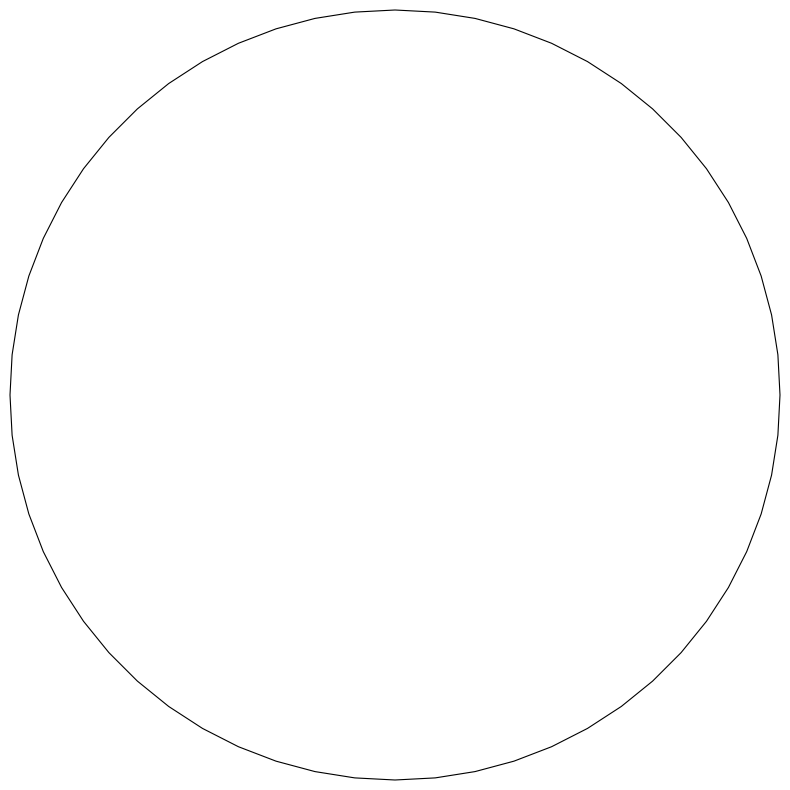

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import xarray as xr

# 1. Load the wind data (U and V vector components)
# dataset = xr.open_dataset('wind_data.nc')
# u_wind = dataset['u']
# v_wind = dataset['v']
# wind_speed = np.sqrt(u_wind**2 + v_wind**2)

# 2. Set up the Orthographic (Globe) Projection
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.Orthographic(central_longitude=-90.0, central_latitude=30.0))

# 3. Add faint coastlines (like in the image)
ax.coastlines(color='white', alpha=0.3)
ax.set_global()

# 4. Plot the streamlines
# We use a colormap that goes from blue -> green -> red -> purple -> white
strm = ax.streamplot(
    longitude_array, latitude_array, 
    u_wind, v_wind, 
    color=wind_speed, 
    cmap='gist_ncar', # Similar colorful map
    linewidth=1.5, 
    density=3.0, 
    transform=ccrs.PlateCarree()
)

plt.show()